The Required Files are avaliable in the Google Drive which can be accessed through Readme file in Github Repository

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import time
import os
from google.colab import drive
from sklearn.neighbors import NearestNeighbors

In [2]:

#The Required Files are avaliable in the Google Drive which can be accessed through Readme file in Github Repository
# File paths - update these to your actual file locations
FEATURES_CSV = 'custom_labels.csv' #custom_labels.csv is avaliable in google drive which can be accessed through Readme file 
DISEASE_CSV = 'extracted_features.csv' #extracted_features.csv is avaliable in google drive which can be accessed through Readme file
OUTPUT_DIR = 'processed_data' #Modify path to the output director

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Mounted at /content/drive


In [3]:
def limit_no_finding_to_percent(df, target_percent=15):
    
    print(f"Adjusting 'No Finding' samples to {target_percent}% of the entire dataset...")

    # Check if 'No Finding' column exists in the DataFrame
    if 'No Finding' not in df.columns:
        print("Warning: 'No Finding' label not found in the data. Returning original data.")
        return df  # Return unmodified DataFrame if column is missing

    # Identify indices where 'No Finding' is marked as 1
    no_finding_indices = df[df['No Finding'] == 1].index
    total_no_finding = len(no_finding_indices)  # Current number of 'No Finding' samples

    total_samples = len(df)  # Total number of samples
    other_samples = total_samples - total_no_finding  # Samples that are not 'No Finding'

    # Calculate the maximum number of 'No Finding' samples allowed to achieve the target percentage
    target_no_finding = int((target_percent / 100 * other_samples) / (1 - target_percent / 100))

    # Log current and target statistics
    print(f"Total samples: {total_samples}")
    print(f"Current 'No Finding' samples: {total_no_finding} ({total_no_finding / total_samples * 100:.2f}%)")
    print(f"Target 'No Finding' samples: {target_no_finding} ({target_percent:.2f}%)")

    if total_no_finding > target_no_finding:
        # If too many 'No Finding' samples, randomly remove the excess
        n_to_remove = total_no_finding - target_no_finding

        np.random.seed(RANDOM_SEED)  # For reproducibility
        indices_to_remove = np.random.choice(no_finding_indices, size=n_to_remove, replace=False)

        # Drop the selected rows from the DataFrame
        df_filtered = df.drop(indices_to_remove)

        print(f"Removed {n_to_remove} 'No Finding' samples")
    else:
        # If current count is already within limits, keep the dataset unchanged
        print(f"Current 'No Finding' count ({total_no_finding}) is already below target ({target_no_finding}). Keeping all.")
        df_filtered = df

    # Final stats after filtering
    final_total = len(df_filtered)
    final_no_finding = df_filtered['No Finding'].sum()
    final_percent = (final_no_finding / final_total) * 100

    print(f"Final 'No Finding' samples: {final_no_finding} ({final_percent:.2f}% of {final_total} total samples)")

    return df_filtered  # Return the updated DataFrame


In [4]:
def increase_rare_classes_to_min(X, y, min_samples=1000):
    """Increase rare classes to have at least min_samples."""
    X_new, y_new = X.copy(), y.copy()

    rare_labels = []
    for label in y.columns:
        count = y[label].sum()
        if count < min_samples and count > 0:
            rare_labels.append((label, count))

    print(f"Found {len(rare_labels)} classes with fewer than {min_samples} samples")

    for label, count in rare_labels:
        print(f"\nProcessing {label} (current count: {count})")

        # Get positive samples for this label
        pos_indices = y[y[label] == 1].index

        # Calculate centroid of positive samples
        centroid = X.loc[pos_indices].mean().values

        # Number of synthetic samples to create
        n_synthetic = min_samples - count

        # Generate with varying noise scales for better generalization
        synthetic_X = []
        synthetic_y = []

        # Use multiple noise scales
        noise_scales = [0.05, 0.1, 0.15, 0.2]  # Different noise levels
        samples_per_scale = n_synthetic // len(noise_scales) + 1

        for noise_scale_factor in noise_scales:
            for _ in tqdm(range(samples_per_scale), desc=f"Generating samples with noise {noise_scale_factor}"):
                if len(synthetic_X) >= n_synthetic:
                    break

                # Pick a random positive sample
                idx = np.random.choice(pos_indices)
                sample = X.loc[idx].values

                # Calculate distance from centroid
                distance = np.linalg.norm(sample - centroid)
                noise_scale = distance * noise_scale_factor

                # Add noise to create new sample
                noise = np.random.normal(0, noise_scale, size=len(sample))
                synthetic_sample = sample + noise

                # Copy the label row
                synthetic_label = y.loc[idx].copy()

                synthetic_X.append(synthetic_sample)
                synthetic_y.append(synthetic_label)

        if synthetic_X:
            # Convert to DataFrames
            X_synthetic = pd.DataFrame(synthetic_X, columns=X.columns)
            y_synthetic = pd.DataFrame(synthetic_y, columns=y.columns)

            # Add to dataset
            X_new = pd.concat([X_new, X_synthetic], ignore_index=True)
            y_new = pd.concat([y_new, y_synthetic], ignore_index=True)

            print(f"  - Added {len(synthetic_X)} synthetic samples for {label}")

    return X_new, y_new

In [5]:
def generate_synthetic_for_multilabel(X, y, min_samples=15):
    """Generate synthetic samples for multi-label combinations using triangle centroids."""
    X_new, y_new = X.copy(), y.copy()

    # Find all multi-label combinations
    y_binary = y.astype(int).astype(str).apply(''.join, axis=1)

    # Count each combination
    label_combinations = {}
    for i, binary_str in enumerate(y_binary):
        if binary_str not in label_combinations:
            label_combinations[binary_str] = []
        label_combinations[binary_str].append(i)

    # Find rare multi-label combinations (exclude all zeros and single label)
    rare_combinations = {}
    for binary_str, indices in label_combinations.items():
        if len(indices) < min_samples and binary_str != '0' * len(y.columns):
            # Convert binary string back to column indices
            columns = [y.columns[i] for i, char in enumerate(binary_str) if char == '1']
            if len(columns) > 1:  # Only include multi-label combinations
                rare_combinations[tuple(columns)] = indices

    print(f"Found {len(rare_combinations)} rare multi-label combinations")

    # Generate synthetic samples for each rare combination
    for label_combination, indices in tqdm(rare_combinations.items(),
                                          desc="Generating multi-label samples",
                                          unit="combination"):
        if len(indices) == 0:
            continue

        print(f"Generating samples for combination: {label_combination} (count: {len(indices)})")

        # Calculate individual centroids for each label in the combination
        label_centroids = []
        for label in label_combination:
            label_indices = y[y[label] == 1].index
            label_centroid = X.loc[label_indices].mean().values
            label_centroids.append(label_centroid)

        # Calculate the centroid of the centroids (triangle centroid)
        if len(label_centroids) > 0:
            triangle_centroid = np.mean(label_centroids, axis=0)

            # Calculate the centroid of the existing combination samples
            combination_centroid = X.iloc[indices].mean().values

            # Use a weighted average of triangle centroid and combination centroid
            final_centroid = 0.5 * triangle_centroid + 0.5 * combination_centroid

            # Number of synthetic samples to create
            n_synthetic = max(0, min_samples - len(indices))

            # Generate synthetic samples
            synthetic_X = []
            synthetic_y = []

            # Multiple noise scales for better diversity
            noise_scales = [0.05, 0.1, 0.15]
            samples_per_scale = n_synthetic // len(noise_scales) + 1

            for noise_scale_factor in noise_scales:
                for _ in range(samples_per_scale):
                    if len(synthetic_X) >= n_synthetic:
                        break

                    # Pick a random sample with this combination
                    idx = indices[np.random.choice(len(indices))]
                    sample = X.iloc[idx].values

                    # Calculate distance from centroid
                    distance = np.linalg.norm(sample - final_centroid)
                    noise_scale = distance * noise_scale_factor

                    # Add noise to create new sample
                    noise = np.random.normal(0, noise_scale, size=len(sample))
                    synthetic_sample = sample + noise

                    # Copy the label row
                    synthetic_label = y.iloc[idx].copy()

                    synthetic_X.append(synthetic_sample)
                    synthetic_y.append(synthetic_label)

            if synthetic_X:
                # Convert to DataFrames
                X_synthetic = pd.DataFrame(synthetic_X, columns=X.columns)
                y_synthetic = pd.DataFrame(synthetic_y, columns=y.columns)

                # Add to dataset
                X_new = pd.concat([X_new, X_synthetic], ignore_index=True)
                y_new = pd.concat([y_new, y_synthetic], ignore_index=True)

                print(f"  - Added {len(synthetic_X)} synthetic samples for combination {label_combination}")

    return X_new, y_new

In [6]:
def apply_mlsmote(X, y, k_neighbors=5):
    """Apply ML-SMOTE to further augment multi-label data."""
    # This is a simplified version of ML-SMOTE for multi-label data
    print("Applying ML-SMOTE for multi-label augmentation...")

    X_new, y_new = X.copy(), y.copy()

    # Find samples with multiple labels
    multilabel_indices = []
    for idx, row in y.iterrows():
        if row.sum() > 1:  # Sample has multiple labels
            multilabel_indices.append(idx)

    print(f"Found {len(multilabel_indices)} multi-label samples")

    if len(multilabel_indices) < k_neighbors + 1:
        print("Not enough multi-label samples for ML-SMOTE. Returning original data.")
        return X, y

    # Extract multi-label samples
    X_multi = X.loc[multilabel_indices]
    y_multi = y.loc[multilabel_indices]

    # Fit nearest neighbors model
    nn = NearestNeighbors(n_neighbors=k_neighbors+1)  # +1 because the sample itself is included
    nn.fit(X_multi)

    # For each multi-label sample, generate a synthetic sample
    synthetic_X = []
    synthetic_y = []

    for i, idx in enumerate(tqdm(multilabel_indices, desc="Generating ML-SMOTE samples")):
        # Find k nearest neighbors
        distances, indices = nn.kneighbors(X.loc[idx].values.reshape(1, -1))

        # Skip the first neighbor (the sample itself)
        neighbor_indices = indices[0][1:]

        # Select a random neighbor
        neighbor_idx = multilabel_indices[np.random.choice(neighbor_indices)]

        # Create synthetic sample
        alpha = np.random.random()
        synthetic_sample = X.loc[idx].values + alpha * (X.loc[neighbor_idx].values - X.loc[idx].values)

        # Combine labels using logical OR
        synthetic_label = y.loc[idx] | y.loc[neighbor_idx]

        synthetic_X.append(synthetic_sample)
        synthetic_y.append(synthetic_label)

    # Convert to DataFrames
    X_synthetic = pd.DataFrame(synthetic_X, columns=X.columns)
    y_synthetic = pd.DataFrame(synthetic_y, columns=y.columns)

    # Add to dataset
    X_new = pd.concat([X_new, X_synthetic], ignore_index=True)
    y_new = pd.concat([y_new, y_synthetic], ignore_index=True)

    print(f"Added {len(synthetic_X)} ML-SMOTE samples")

    return X_new, y_new

In [7]:
def plot_class_distribution(y_data, title="Class Distribution"):
    """Plot the distribution of classes in the dataset."""
    class_counts = y_data.sum().sort_values(ascending=False)

    plt.figure(figsize=(14, 7))
    ax = sns.barplot(x=class_counts.index, y=class_counts.values)
    plt.xticks(rotation=45, ha='right')
    plt.title(title, fontsize=16)
    plt.xlabel('Class', fontsize=14)
    plt.ylabel('Count', fontsize=14)

    # Add count labels on top of bars
    for i, p in enumerate(ax.patches):
        percentage = class_counts.values[i] / len(y_data) * 100
        ax.annotate(f"{int(class_counts.values[i])}\n({percentage:.1f}%)",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points')

    # Create a valid filename with no spaces
    filename = title.replace(" ", "_").replace("(", "").replace(")", "").lower()

    # Ensure the OUTPUT_DIR exists
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Save the figure
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}.png', dpi=300)
    plt.show()

    return class_counts

In [8]:
def add_split_column(df, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2):

    # Ensure that the provided split ratios sum to 1
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-10, "Ratios must sum to 1"

    # Default all rows to 'train' initially
    df['split'] = 'train'

    # Shuffle indices to randomize the split
    np.random.seed(RANDOM_SEED)  # Use a seed for reproducibility
    indices = np.random.permutation(len(df))  # Random permutation of indices

    # Compute split cutoff indices based on ratios
    train_end = int(train_ratio * len(df))
    val_end = int((train_ratio + val_ratio) * len(df))

    # Get validation and test indices based on computed cutoffs
    val_indices = indices[train_end:val_end]
    test_indices = indices[val_end:]

    # Assign split labels to the appropriate indices
    df.loc[df.index[val_indices], 'split'] = 'validation'
    df.loc[df.index[test_indices], 'split'] = 'test'

    # Display split distribution
    split_counts = df['split'].value_counts()
    print("Data split counts:")
    for split, count in split_counts.items():
        print(f"  - {split}: {count} ({count / len(df) * 100:.1f}%)")

    return df  # Return updated DataFrame with split column


In [9]:
def process_and_augment_data():
    """Complete data processing and augmentation pipeline."""
    start_time = time.time()

    print("="*80)
    print("NIH CHEST X-RAY DATA PROCESSING AND AUGMENTATION")
    print("="*80)

    # Step 1: Load raw data
    print("\nStep 1: Loading raw data...")
    feature_df = pd.read_csv(FEATURES_CSV)
    disease_df = pd.read_csv(DISEASE_CSV)

    # Merge datasets
    print("Merging datasets...")
    df = pd.merge(feature_df, disease_df, on='Image Index')

    # Define columns to drop (keep 'Image Index' for reference)
    columns_to_drop = [
        'Finding Labels', 'Follow-up #', 'Patient ID',
        'Patient Age', 'Patient Gender', 'View Position',
        'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]'
    ]

    # Drop unnecessary columns
    df_cleaned = df.drop(columns=columns_to_drop)

    # Define label columns
    label_columns = [
        'Fibrosis', 'Hernia', 'Nodule', 'Consolidation', 'No Finding',
        'Atelectasis', 'Pneumonia', 'Cardiomegaly', 'Emphysema',
        'Infiltration', 'Pleural_Thickening', 'Mass',
        'Effusion', 'Pneumothorax', 'Edema'
    ]

    # Define feature columns
    feature_columns = [col for col in df_cleaned.columns if col.startswith('feature_')]

    # Analyze original class distribution
    print("\nOriginal class distribution:")
    original_counts = plot_class_distribution(df_cleaned[label_columns], "Original Class Distribution")

    # Step 2: Limit 'No Finding' to 15% of the dataset
    print("\nStep 2: Limiting 'No Finding' to 15% of the dataset...")
    df_filtered = limit_no_finding_to_percent(df_cleaned, target_percent=15)

    # Analyze filtered class distribution
    print("\nFiltered class distribution:")
    filtered_counts = plot_class_distribution(df_filtered[label_columns], "Filtered Class Distribution")

    # Step 3: Extract features and labels
    print("\nStep 3: Extracting features and labels...")
    X = df_filtered[feature_columns]
    y = df_filtered[label_columns]
    image_ids = df_filtered['Image Index']

    # Step 4: Increase rare classes to minimum 1000 samples
    print("\nStep 4: Increasing rare classes to minimum 1000 samples...")
    X_aug1, y_aug1 = increase_rare_classes_to_min(X, y, min_samples=1000)

    # Analyze distribution after rare class augmentation
    print("\nDistribution after rare class augmentation:")
    rare_aug_counts = plot_class_distribution(y_aug1, "Distribution After Rare Class Augmentation")

    # Step 5: Generate synthetic samples for multi-label combinations
    print("\nStep 5: Generating synthetic samples for multi-label combinations...")
    X_aug2, y_aug2 = generate_synthetic_for_multilabel(X_aug1, y_aug1, min_samples=15)

    # Analyze distribution after multi-label augmentation
    print("\nDistribution after multi-label augmentation:")
    multilabel_aug_counts = plot_class_distribution(y_aug2, "Distribution After Multi-label Augmentation")

    # Step 6: Apply ML-SMOTE for further multi-label augmentation
    print("\nStep 6: Applying ML-SMOTE for further multi-label augmentation...")
    X_aug3, y_aug3 = apply_mlsmote(X_aug2, y_aug2)

    # Analyze final distribution
    print("\nFinal distribution after all augmentations:")
    final_counts = plot_class_distribution(y_aug3, "Final Distribution After All Augmentations")

    # Step 7: Add split column
    print("\nStep 7: Adding split column...")
    # Create a dataframe with all the data
    final_df = pd.concat([image_ids.reset_index(drop=True),
                           X_aug3.reset_index(drop=True),
                           y_aug3.reset_index(drop=True)], axis=1)

    # Add synthetic sample indicator for new rows
    final_df['is_synthetic'] = 0
    final_df.loc[len(df_filtered):, 'is_synthetic'] = 1
    final_df.loc[len(df_filtered):, 'Image Index'] = [f'synthetic_{i}' for i in range(len(final_df) - len(df_filtered))]

    # Add split column
    final_df = add_split_column(final_df)

    # Step 8: Save the final dataset
    print("\nStep 8: Saving the final dataset...")
    output_path = f'{OUTPUT_DIR}/nih_chestxray_augmented.csv'
    final_df.to_csv(output_path, index=False)

    print(f"Saved final augmented dataset to: {output_path}")
    print(f"  - Total rows: {len(final_df)}")
    print(f"  - Original samples: {len(df_filtered)}")
    print(f"  - Synthetic samples: {len(final_df) - len(df_filtered)}")
    print(f"  - Total columns: {len(final_df.columns)}")

    # Save distribution comparison
    distribution_comparison = pd.DataFrame({
        'Label': original_counts.index,
        'Original_Count': original_counts.values,
        'Original_Percent': original_counts.values / len(df) * 100,
        'Filtered_Count': filtered_counts.values,
        'Filtered_Percent': filtered_counts.values / len(df_filtered) * 100,
        'Final_Count': final_counts.values,
        'Final_Percent': final_counts.values / len(final_df) * 100
    })

    distribution_comparison.to_csv(f'{OUTPUT_DIR}/distribution_comparison.csv', index=False)

    # Save column information
    with open(f'{OUTPUT_DIR}/feature_columns.txt', 'w') as f:
        f.write('\n'.join(feature_columns))

    with open(f'{OUTPUT_DIR}/label_columns.txt', 'w') as f:
        f.write('\n'.join(label_columns))

    # Calculate execution time
    total_time = time.time() - start_time

    print("\n"+"="*80)
    print("DATA PROCESSING AND AUGMENTATION COMPLETED SUCCESSFULLY")
    print(f"Total execution time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    print("="*80)

    return final_df

NIH CHEST X-RAY DATA PROCESSING AND AUGMENTATION

Step 1: Loading raw data...
Merging datasets...

Original class distribution:


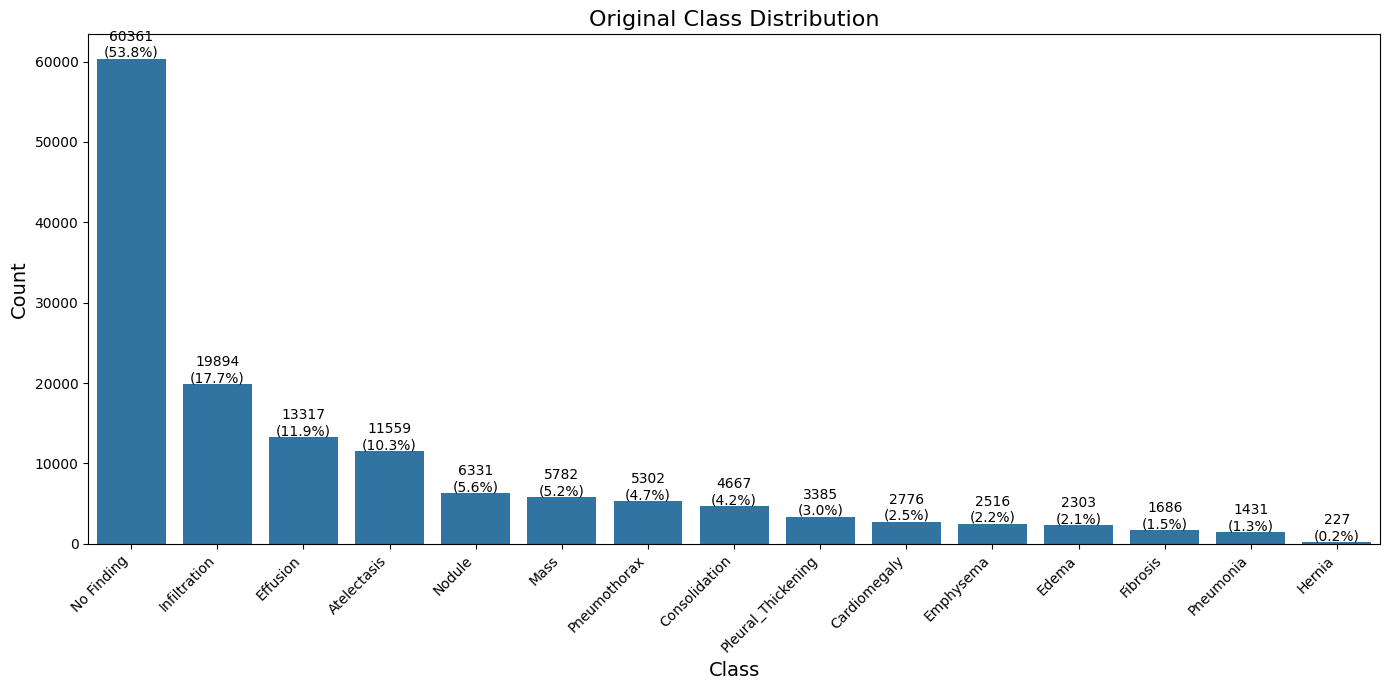


Step 2: Limiting 'No Finding' to 15% of the dataset...
Adjusting 'No Finding' samples to 15% of the entire dataset...
Total samples: 112120
Current 'No Finding' samples: 60361 (53.84%)
Target 'No Finding' samples: 9133 (15.00%)
Removed 51228 'No Finding' samples
Final 'No Finding' samples: 9133 (15.00% of 60892 total samples)

Filtered class distribution:


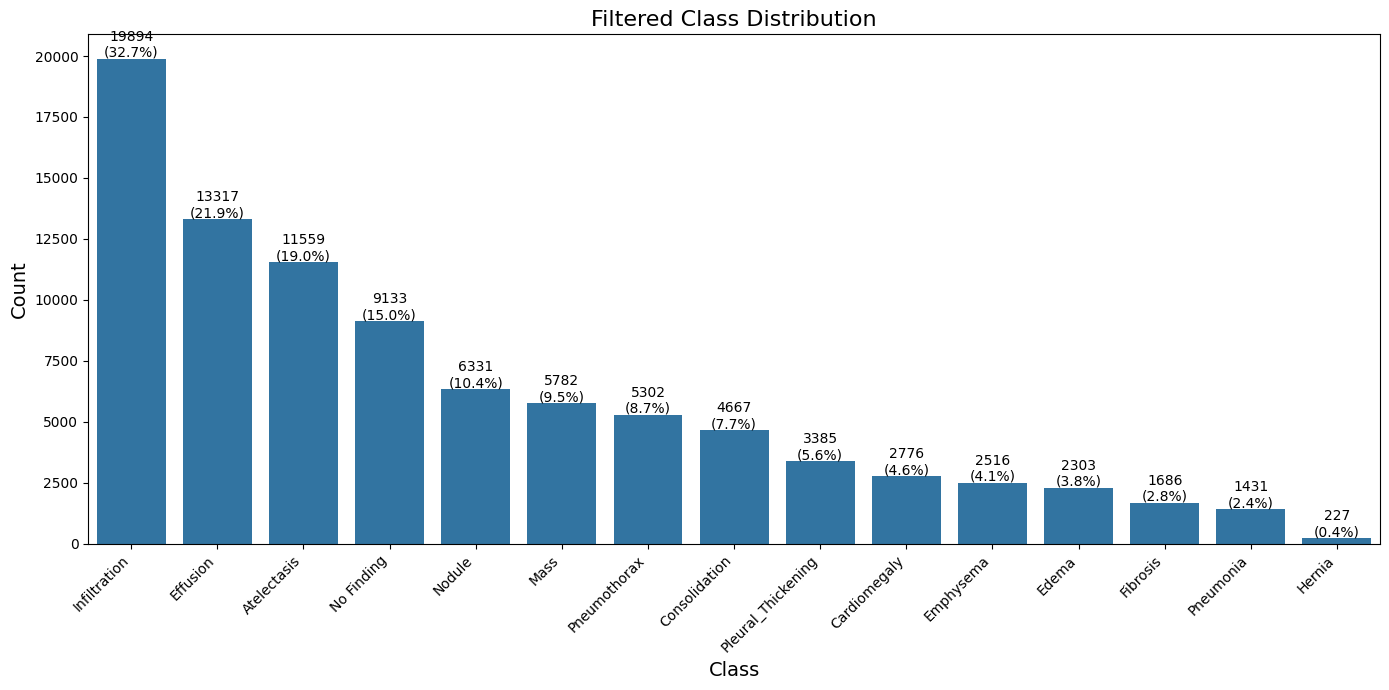


Step 3: Extracting features and labels...

Step 4: Increasing rare classes to minimum 1000 samples...
Found 1 classes with fewer than 1000 samples

Processing Hernia (current count: 227)


Generating samples with noise 0.05:   0%|          | 0/194 [00:00<?, ?it/s]

Generating samples with noise 0.1:   0%|          | 0/194 [00:00<?, ?it/s]

Generating samples with noise 0.15:   0%|          | 0/194 [00:00<?, ?it/s]

Generating samples with noise 0.2:   0%|          | 0/194 [00:00<?, ?it/s]

  - Added 773 synthetic samples for Hernia

Distribution after rare class augmentation:


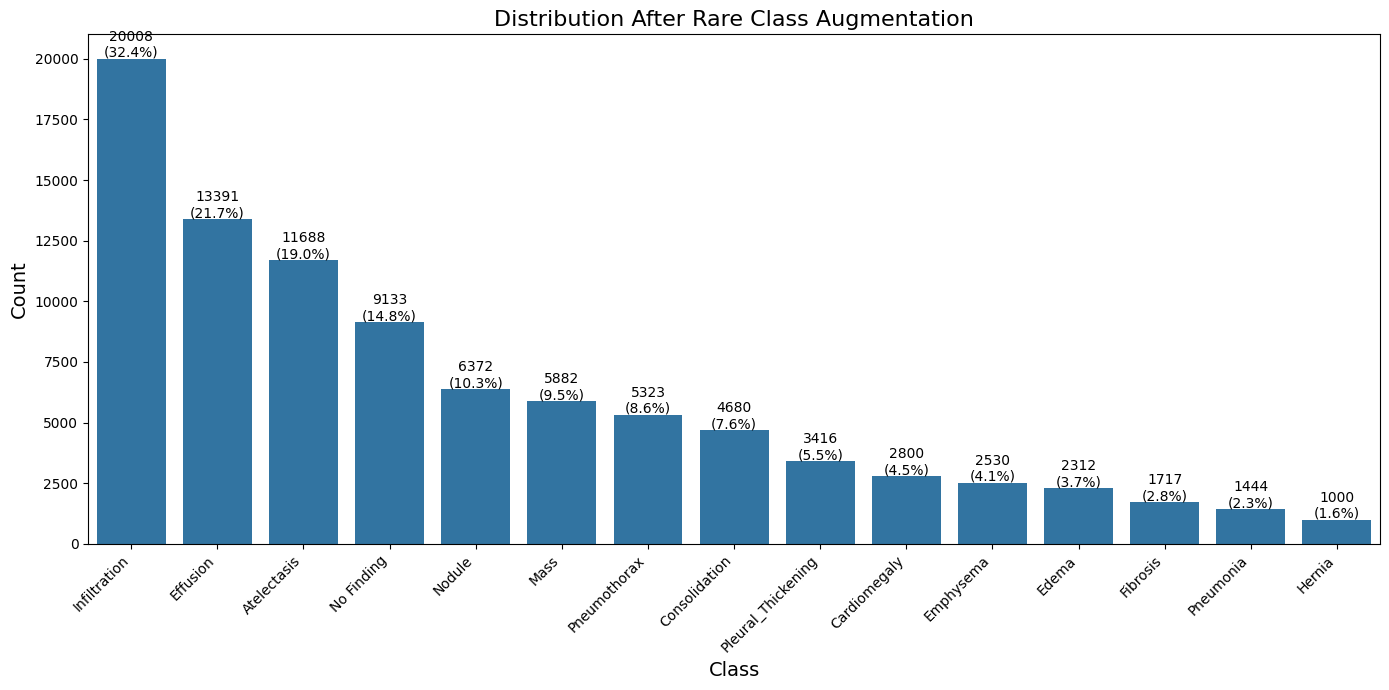


Step 5: Generating synthetic samples for multi-label combinations...
Found 612 rare multi-label combinations


Generating multi-label samples:   0%|          | 0/612 [00:00<?, ?combination/s]

Generating samples for combination: ('Emphysema', 'Infiltration', 'Effusion', 'Pneumothorax') (count: 12)
  - Added 3 synthetic samples for combination ('Emphysema', 'Infiltration', 'Effusion', 'Pneumothorax')
Generating samples for combination: ('Emphysema', 'Infiltration', 'Pleural_Thickening', 'Pneumothorax') (count: 6)
  - Added 9 synthetic samples for combination ('Emphysema', 'Infiltration', 'Pleural_Thickening', 'Pneumothorax')
Generating samples for combination: ('Pneumonia', 'Effusion', 'Pneumothorax') (count: 4)
  - Added 11 synthetic samples for combination ('Pneumonia', 'Effusion', 'Pneumothorax')
Generating samples for combination: ('Nodule', 'Cardiomegaly', 'Infiltration', 'Mass') (count: 2)
  - Added 13 synthetic samples for combination ('Nodule', 'Cardiomegaly', 'Infiltration', 'Mass')
Generating samples for combination: ('Cardiomegaly', 'Emphysema', 'Mass', 'Effusion') (count: 3)
  - Added 12 synthetic samples for combination ('Cardiomegaly', 'Emphysema', 'Mass', 'Effu

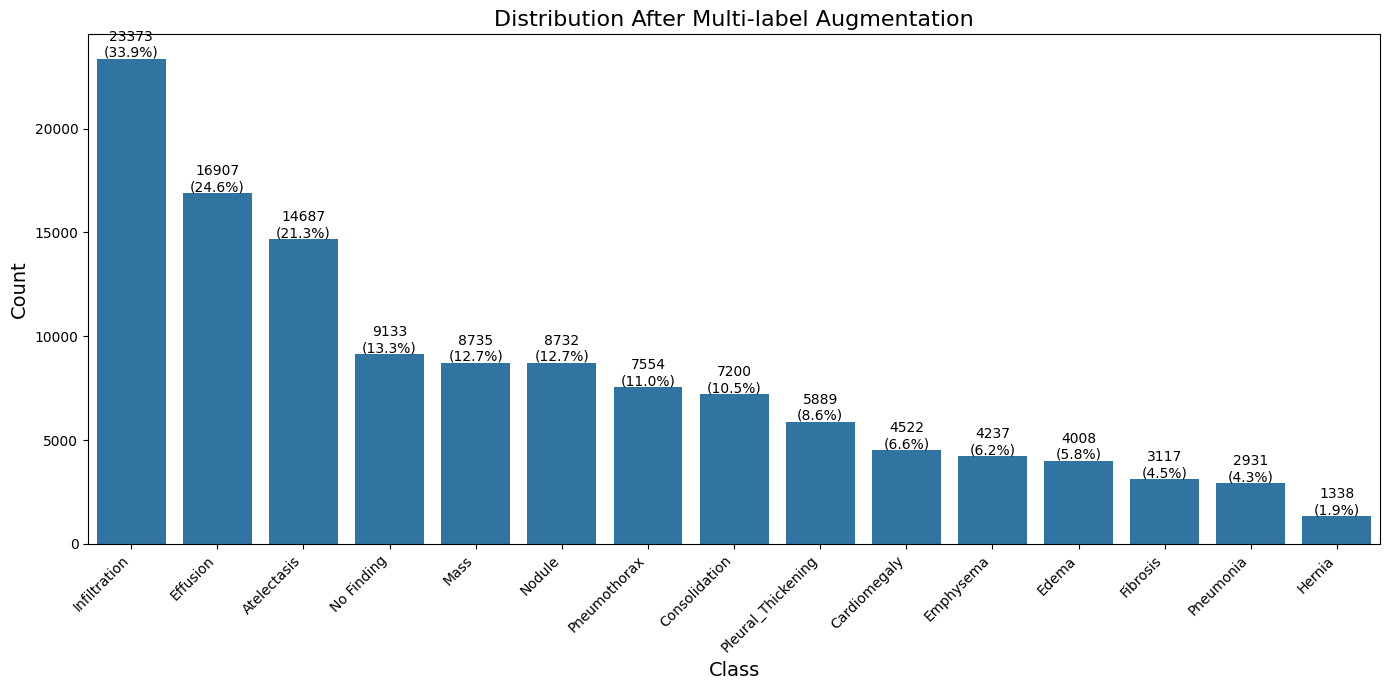


Step 6: Applying ML-SMOTE for further multi-label augmentation...
Applying ML-SMOTE for multi-label augmentation...
Found 28396 multi-label samples


Generating ML-SMOTE samples:   0%|          | 0/28396 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warn

Added 28396 ML-SMOTE samples

Final distribution after all augmentations:


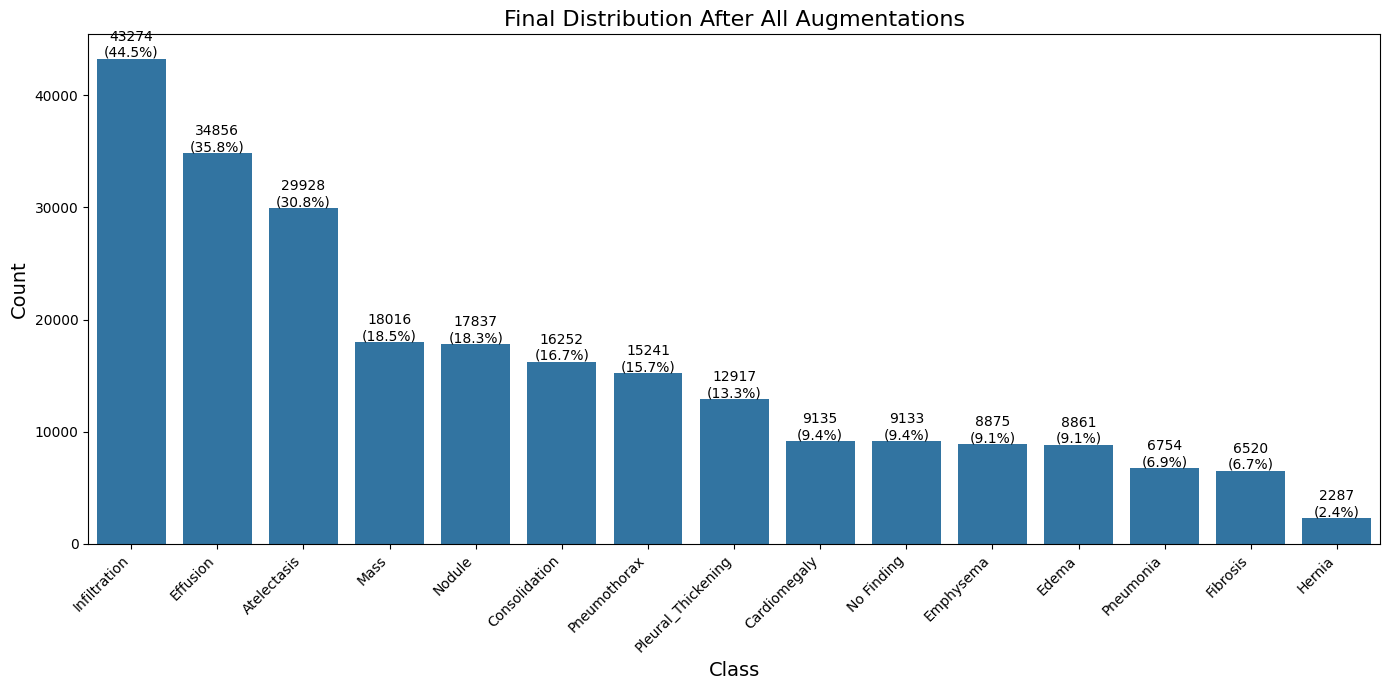


Step 7: Adding split column...
Data split counts:
  - train: 58354 (60.0%)
  - test: 19452 (20.0%)
  - validation: 19451 (20.0%)

Step 8: Saving the final dataset...
Saved final augmented dataset to: /content/drive/MyDrive/Ml_Project/processed_data/nih_chestxray_augmented.csv
  - Total rows: 97257
  - Original samples: 60892
  - Synthetic samples: 36365
  - Total columns: 1042

DATA PROCESSING AND AUGMENTATION COMPLETED SUCCESSFULLY
Total execution time: 870.36 seconds (14.51 minutes)


In [10]:
if __name__ == "__main__":
    augmented_data = process_and_augment_data()